# EDM UNet: Training-Set-Size Sweep — Memorization Study

Follow-up to `edm_tikhonov_memorization.ipynb`, per the professor's suggestion:

> "For the UNet, I would consider what happens when you reduce the size of the training set
> first. I believe in iterating quickly to get to a desired result and this seems like the
> first approach to try."

The unregularized EDM UNet at n_train = 32 shows only partial memorization, which makes
regularization effects hard to read. Reducing n_train should push the UNet toward the strong
memorization regime (where the closed-form GMM sits by construction), giving a cleaner
baseline against which Tikhonov-style regularizers can be evaluated.

**Design (everything mirrors `edm_tikhonov_memorization.ipynb` unless noted):**
- n_train ∈ [4, 8, 16, 32], nested subsets of the same 200-sample pool. n_train = 32 with
  c_tikhonov = 0 reproduces the unregularized baseline from the previous notebook (same
  seed, architecture, and training budget).
- Full-batch training (batch_size = n_train), 5000 steps, checkpoints at [1000, 3000, 5000].
  The number of gradient steps is held fixed across n_train, so differences come from
  dataset size, not training budget (same convention as Task 4 of
  `memorization_regime_sweep.ipynb`, which swept n_train ∈ [8, 16, 32, 64] for the VP-SDE
  epsilon-prediction UNet at 1000 steps).
- Sampling: VE_EDM SDE, 500 steps, 16 generated samples from latents fixed by seed 42.
- Reference: the closed-form GMM score (perfect memorizer) at the same n_train and latents —
  the memorization ceiling for each dataset size.

**Runtime:** 4 trainings × 5000 full-batch steps + 16 samplings × 500 SDE steps — comparable
to (slightly less than) the previous notebook's full run on CPU.

In [1]:
import sys, os, math, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -- path setup --
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
src_dir = os.path.join(repo_root, 'src')
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import diffusion_score_models as score_models
from multiband_data_utils import (
    generate_multiband_dataset_postmask,
    make_radial_band_mask,
    radial_bandpass,
    make_radial_k_grid,
)
from edm import EDMPrecond, EDMScoreWrapper, train_edm

device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'device: {device}')

device: cpu


In [2]:
# ── Data generation (same pool as edm_tikhonov_memorization) ──
components = [
    {"name": "coarse", "length_scale": 2.0,  "s": 2.0, "sigma_sq": 1.0, "band": (0.5, 4.0)},
    {"name": "mid1",   "length_scale": 6.0,  "s": 2.0, "sigma_sq": 1.0, "band": (4.0, 10.0)},
    {"name": "mid2",   "length_scale": 12.0, "s": 2.0, "sigma_sq": 1.0, "band": (10.0, 18.0)},
    {"name": "fine",   "length_scale": 24.0, "s": 2.0, "sigma_sq": 1.0, "band": (18.0, 32.0)},
]

result = generate_multiband_dataset_postmask(
    num_samples=200, grid_size=128, components=components,
    weights=[1.0, 0.8, 0.8, 1.2], seed=42, normalize=True,
)
bands = result.get('bands', {c['name']: c['band'] for c in components})
N = 128
x_all = result['combined'].to(device)   # (200, 128, 128) — sliced per n_train below

print(f'Data pool: {x_all.shape}')
print(f'Bands: {bands}')

Data pool: torch.Size([200, 128, 128])
Bands: {'coarse': (0.5, 4.0), 'mid1': (4.0, 10.0), 'mid2': (10.0, 18.0), 'fine': (18.0, 32.0)}


In [3]:
# ── SmallUNet architecture (identical to edm_tikhonov_memorization) ──

class SinusoidalEmbedding(nn.Module):
    """Standard sinusoidal time embedding, maps scalar t -> vector of size dim."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, dtype=torch.float32, device=t.device) / (half - 1)
        )
        args = t.float()[:, None] * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ResBlock(nn.Module):
    """Conv residual block with additive time embedding."""
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        def ngroups(ch):
            for g in [8, 4, 2, 1]:
                if ch % g == 0: return g
        self.norm1    = nn.GroupNorm(ngroups(in_ch),  in_ch)
        self.conv1    = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.norm2    = nn.GroupNorm(ngroups(out_ch), out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.skip     = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.emb_proj(F.silu(emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class SmallUNet(nn.Module):
    """
    2-level U-Net: 128->64->32 (spatial), then back up.
    Predicts a denoised image given noisy input and conditioning scalar.
    """
    def __init__(self, base_channels=16, emb_dim=64):
        super().__init__()
        C, E = base_channels, emb_dim
        self.time_embed = nn.Sequential(
            SinusoidalEmbedding(E), nn.Linear(E, E*2), nn.SiLU(), nn.Linear(E*2, E)
        )
        self.conv_in = nn.Conv2d(1,   C,   3, padding=1)
        self.enc1    = ResBlock(C,   C,   E)
        self.down1   = nn.Conv2d(C,  C*2, 3, stride=2, padding=1)   # 128->64
        self.enc2    = ResBlock(C*2, C*2, E)
        self.down2   = nn.Conv2d(C*2, C*4, 3, stride=2, padding=1)  # 64->32
        self.mid     = ResBlock(C*4, C*4, E)
        self.up2     = nn.ConvTranspose2d(C*4, C*2, 2, stride=2)    # 32->64
        self.dec2    = ResBlock(C*4, C*2, E)   # skip concat
        self.up1     = nn.ConvTranspose2d(C*2, C,   2, stride=2)    # 64->128
        self.dec1    = ResBlock(C*2, C,   E)   # skip concat
        self.conv_out = nn.Conv2d(C, 1, 3, padding=1)
    def forward(self, x, t):
        emb = self.time_embed(t)
        h   = self.conv_in(x)
        h1  = self.enc1(h,  emb)
        h2  = self.enc2(self.down1(h1), emb)
        hm  = self.mid( self.down2(h2), emb)
        hu  = self.dec2(torch.cat([self.up2(hm), h2], dim=1), emb)
        hu  = self.dec1(torch.cat([self.up1(hu), h1], dim=1), emb)
        return self.conv_out(hu)


print(f'SmallUNet params: {sum(p.numel() for p in SmallUNet().parameters()):,}')

SmallUNet params: 195,697


In [4]:
# ── Analysis helpers (same as edm_tikhonov_memorization / analyze_coarse_fine_memorization.py) ──

@torch.no_grad()
def band_component(x, band, norm='forward'):
    if x.dim() == 2:
        x = x.unsqueeze(0)
    k_lo, k_hi = band
    m = make_radial_band_mask(x.shape[-1], k_lo, k_hi, device=x.device, dtype=x.dtype)
    return radial_bandpass(x, m, norm=norm)


@torch.no_grad()
def nn_by_coarse(x_gen, x_train, coarse_band):
    cg = band_component(x_gen, coarse_band).flatten(1)
    ct = band_component(x_train, coarse_band).flatten(1)
    D = torch.cdist(cg, ct)
    idx = D.argmin(dim=1)
    return idx, D.min(dim=1).values


def make_ring_masks(N, k_edges, device):
    kr = make_radial_k_grid(N, device=device)
    masks = []
    for lo, hi in zip(k_edges[:-1], k_edges[1:]):
        masks.append(((kr >= lo) & (kr < hi)).float())
    return torch.stack(masks, dim=0)


@torch.no_grad()
def ring_rel_l2(xa, xb, ring_masks, fft_norm=None, eps=1e-12):
    Xa = torch.fft.fft2(xa, dim=(-2, -1), norm=fft_norm)
    Xb = torch.fft.fft2(xb, dim=(-2, -1), norm=fft_norm)
    D = Xa - Xb
    rm = ring_masks.unsqueeze(0).to(Xa.device)
    num = (D.abs() ** 2).unsqueeze(1) * rm
    den = (Xa.abs() ** 2).unsqueeze(1) * rm
    num = num.sum(dim=(-2, -1))
    den = den.sum(dim=(-2, -1)).clamp_min(eps)
    return torch.sqrt(num / den)


@torch.no_grad()
def random_baseline_errors(xg, xtr, ring_masks, n_ref=64, fft_norm=None):
    errs = []
    for _ in range(n_ref):
        rand_idx = torch.randint(0, xtr.shape[0], (xg.shape[0],), device=xtr.device)
        errs.append(ring_rel_l2(xg, xtr[rand_idx], ring_masks, fft_norm=fft_norm))
    return torch.stack(errs, dim=0)  # (n_ref, G, K)


def ring_idx_for_band(band, k_centers):
    lo, hi = band
    return ((k_centers >= lo) & (k_centers < hi)).nonzero().squeeze(1)


@torch.no_grad()
def radial_power_spectrum(x, ring_masks_):
    """Mean per-mode power in each wavenumber ring (orthonormal FFT), averaged over batch."""
    X = torch.fft.fft2(x, dim=(-2, -1), norm='ortho')
    P = X.abs() ** 2
    rm = ring_masks_.to(x.device)
    num = (P.unsqueeze(1) * rm.unsqueeze(0)).sum(dim=(-2, -1))   # (G, K)
    cnt = rm.sum(dim=(-2, -1)).clamp_min(1)
    return (num / cnt).mean(dim=0)                               # (K,)


# Precompute wavenumber grid and ring masks
kmax = float(make_radial_k_grid(N, device=device).max().item())
k_edges = torch.arange(0.5, kmax + 1.5, 1.0, device=device)
ring_masks = make_ring_masks(N, k_edges, device=device)
k_centers = 0.5 * (k_edges[1:] + k_edges[:-1])
coarse_r = ring_idx_for_band(bands['coarse'], k_centers)
fine_r   = ring_idx_for_band(bands['fine'],   k_centers)
print(f'Ring masks: {ring_masks.shape}, k range: [{k_centers[0]:.1f}, {k_centers[-1]:.1f}]')

Ring masks: torch.Size([91, 128, 128]), k range: [1.0, 91.0]


In [5]:
# ── Training-set-size sweep ──
# For each n_train: train the (unregularized) EDM UNet once, evaluate every checkpoint,
# and compute the GMM closed-form reference with the same diffusion and latents.

N_TRAIN_SWEEP = [4, 8, 16, 32]
TOTAL_STEPS   = 5000
CHECKPOINT_AT = [1000, 3000, 5000]
N_GEN         = 16
N_SDE_STEPS   = 500
N_RAND_REF    = 32

ve_edm = score_models.VE_EDM(sigma_min=0.002, sigma_max=80.0)


def memorization_metrics(x_gen, xtr):
    idx_nn, _ = nn_by_coarse(x_gen, xtr, bands['coarse'])
    err_nn = ring_rel_l2(x_gen, xtr[idx_nn], ring_masks)
    err_rand = random_baseline_errors(x_gen, xtr, ring_masks, n_ref=N_RAND_REF)
    ratio = (err_nn.unsqueeze(0) / (err_rand + 1e-12)).mean(dim=0)   # (G, K)
    return {
        'ratio': ratio.cpu(),
        'mean_ratio': ratio.mean(dim=0).cpu(),
        'coarse_score': ratio[:, coarse_r].mean(dim=1).cpu(),
        'fine_score': ratio[:, fine_r].mean(dim=1).cpu(),
    }


sweep_results = {}   # n_train -> {'unet': {step -> metrics}, 'gmm': metrics}

for n_train in N_TRAIN_SWEEP:
    print(f'\n===== n_train = {n_train} =====')
    x_train_img = x_all[:n_train]
    train_data_flat = x_train_img.reshape(n_train, -1).contiguous()
    xtr = x_train_img.detach()

    # -- UNet: train once, evaluate every checkpoint --
    checkpoints = train_edm(
        train_data_flat, grid_size=N,
        total_steps=TOTAL_STEPS, checkpoint_at=CHECKPOINT_AT,
        base_channels=16, emb_dim=64,
        lr=1e-3, batch_size=n_train,   # full-batch
        P_mean=-1.2, P_std=1.2,
        seed=0, device=device,
        UNetClass=SmallUNet,
    )

    unet_res = {}
    for step in CHECKPOINT_AT:
        score_wrapper = EDMScoreWrapper(checkpoints[step], ve_edm.marginal_prob_std,
                                        N, c_tikhonov=0.0).to(device)
        torch.manual_seed(42)
        latents = torch.randn(N_GEN, N*N, device=device)
        samples = ve_edm.SDEsampler(score_wrapper, latents, num_steps=N_SDE_STEPS)
        x_gen = samples.reshape(N_GEN, N, N)
        m = memorization_metrics(x_gen, xtr)
        m['samples'] = x_gen[:4].cpu()
        unet_res[step] = m
        print(f'  UNet step {step}: coarse={m["coarse_score"].mean():.4f}  '
              f'fine={m["fine_score"].mean():.4f}')

    # -- GMM reference (perfect memorizer, same diffusion + latents) --
    score_gmm = score_models.GMM_score(train_data_flat, ve_edm.marginal_prob_mean,
                                       ve_edm.marginal_prob_std).to(device)
    torch.manual_seed(42)
    latents = torch.randn(N_GEN, N*N, device=device)
    samples_gmm = ve_edm.SDEsampler(score_gmm, latents, num_steps=N_SDE_STEPS)
    x_gen_gmm = samples_gmm.reshape(N_GEN, N, N)
    gmm_res = memorization_metrics(x_gen_gmm, xtr)
    gmm_res['samples'] = x_gen_gmm[:4].cpu()
    print(f'  GMM reference: coarse={gmm_res["coarse_score"].mean():.4f}  '
          f'fine={gmm_res["fine_score"].mean():.4f}')

    sweep_results[n_train] = {'unet': unet_res, 'gmm': gmm_res}

print('\nSweep complete.')


===== n_train = 4 =====
Estimated sigma_data = 0.9491
  step 1/5000  loss=1.004498
  step 500/5000  loss=0.132439
  step 1000/5000  loss=0.155361
  >> checkpoint saved at step 1000
  step 1500/5000  loss=0.082390
  step 2000/5000  loss=0.082719
  step 2500/5000  loss=0.048827
  step 3000/5000  loss=0.044297
  >> checkpoint saved at step 3000
  step 3500/5000  loss=0.072672
  step 4000/5000  loss=0.040889
  step 4500/5000  loss=0.048625
  step 5000/5000  loss=0.030999
  >> checkpoint saved at step 5000
  UNet step 1000: coarse=0.9126  fine=1.0053
  UNet step 3000: coarse=0.9212  fine=0.9975
  UNet step 5000: coarse=0.9112  fine=0.9979
  GMM reference: coarse=0.2169  fine=0.2234

===== n_train = 8 =====
Estimated sigma_data = 0.9810
  step 1/5000  loss=0.913795
  step 500/5000  loss=0.118466
  step 1000/5000  loss=0.108786
  >> checkpoint saved at step 1000
  step 1500/5000  loss=0.124451
  step 2000/5000  loss=0.079900
  step 2500/5000  loss=0.075265
  step 3000/5000  loss=0.063926
  >

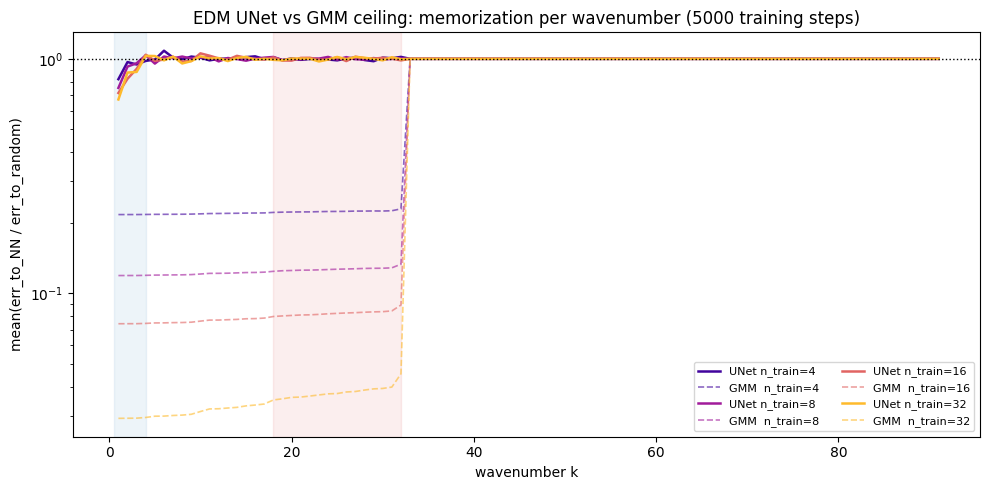

In [6]:
# ── Main figure: mean_ratio(k) per n_train (final checkpoint) with GMM reference ──
kc = k_centers.cpu().numpy()
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(N_TRAIN_SWEEP)))

fig, ax = plt.subplots(figsize=(10, 5))
for color, n_train in zip(colors, N_TRAIN_SWEEP):
    mr_unet = sweep_results[n_train]['unet'][TOTAL_STEPS]['mean_ratio'].numpy()
    mr_gmm  = sweep_results[n_train]['gmm']['mean_ratio'].numpy()
    ax.plot(kc, mr_unet, color=color, lw=1.8, label=f'UNet n_train={n_train}')
    ax.plot(kc, mr_gmm,  color=color, lw=1.2, ls='--', alpha=0.6, label=f'GMM  n_train={n_train}')
ax.axhline(1.0, ls=':', color='black', lw=1)
for bname, bcolor in [('coarse', 'tab:blue'), ('fine', 'tab:red')]:
    lo, hi = bands[bname]
    ax.axvspan(lo, hi, color=bcolor, alpha=0.08)
ax.set_yscale('log')
ax.set_xlabel('wavenumber k')
ax.set_ylabel('mean(err_to_NN / err_to_random)')
ax.set_title(f'EDM UNet vs GMM ceiling: memorization per wavenumber ({TOTAL_STEPS} training steps)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

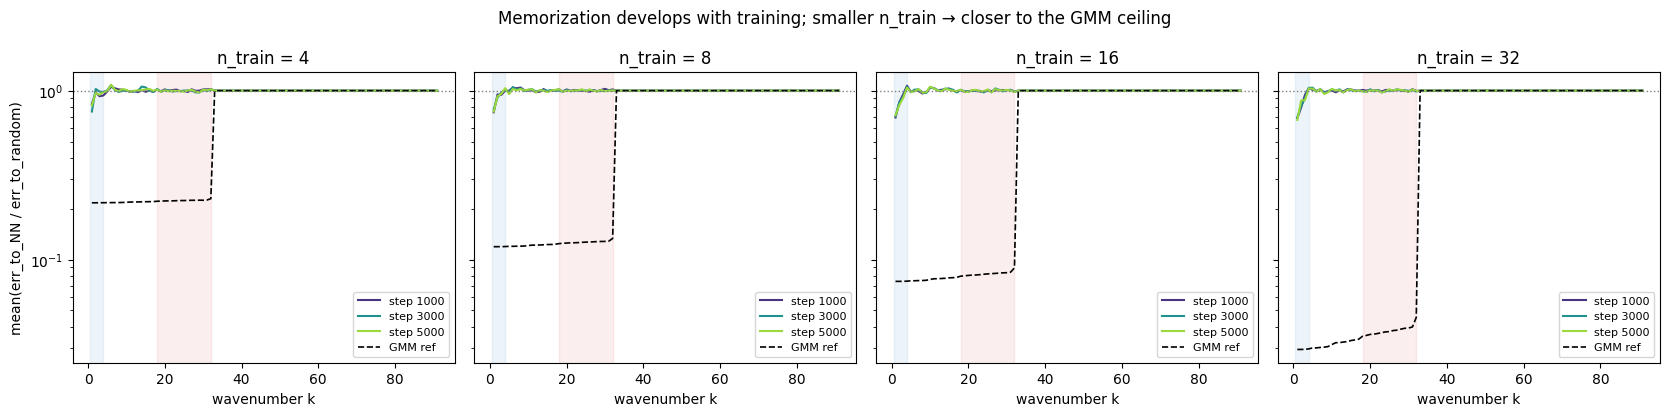

In [7]:
# ── Memorization vs training budget, per dataset size ──
fig, axes = plt.subplots(1, len(N_TRAIN_SWEEP), figsize=(4.2*len(N_TRAIN_SWEEP), 4.2), sharey=True)
step_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(CHECKPOINT_AT)))
for ax, n_train in zip(axes, N_TRAIN_SWEEP):
    for sc, step in zip(step_colors, CHECKPOINT_AT):
        ax.plot(kc, sweep_results[n_train]['unet'][step]['mean_ratio'].numpy(),
                color=sc, lw=1.5, label=f'step {step}')
    ax.plot(kc, sweep_results[n_train]['gmm']['mean_ratio'].numpy(),
            color='black', lw=1.2, ls='--', label='GMM ref')
    ax.axhline(1.0, ls=':', color='gray', lw=1)
    for bname, bcolor in [('coarse', 'tab:blue'), ('fine', 'tab:red')]:
        lo, hi = bands[bname]
        ax.axvspan(lo, hi, color=bcolor, alpha=0.08)
    ax.set_yscale('log')
    ax.set_xlabel('wavenumber k')
    ax.set_title(f'n_train = {n_train}')
    ax.legend(fontsize=8)
axes[0].set_ylabel('mean(err_to_NN / err_to_random)')
fig.suptitle('Memorization develops with training; smaller n_train → closer to the GMM ceiling')
plt.tight_layout()
plt.show()

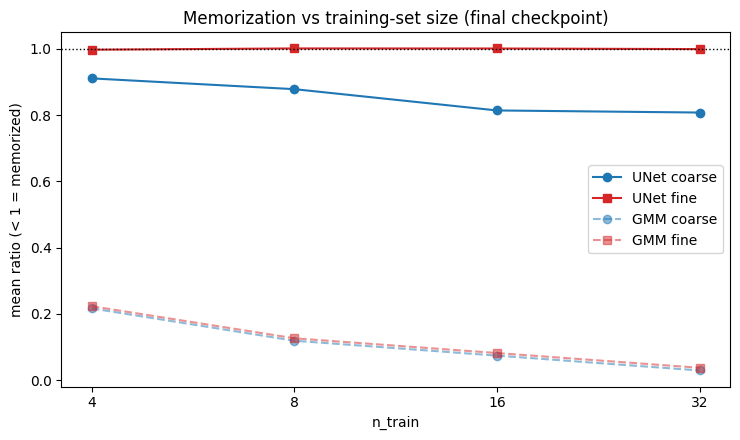

In [8]:
# ── Coarse/fine band scores vs n_train (final checkpoint) ──
coarse_unet = [sweep_results[n]['unet'][TOTAL_STEPS]['coarse_score'].mean().item()
               for n in N_TRAIN_SWEEP]
fine_unet   = [sweep_results[n]['unet'][TOTAL_STEPS]['fine_score'].mean().item()
               for n in N_TRAIN_SWEEP]
coarse_gmm  = [sweep_results[n]['gmm']['coarse_score'].mean().item() for n in N_TRAIN_SWEEP]
fine_gmm    = [sweep_results[n]['gmm']['fine_score'].mean().item()   for n in N_TRAIN_SWEEP]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(N_TRAIN_SWEEP, coarse_unet, 'o-',  color='tab:blue', label='UNet coarse')
ax.plot(N_TRAIN_SWEEP, fine_unet,   's-',  color='tab:red',  label='UNet fine')
ax.plot(N_TRAIN_SWEEP, coarse_gmm,  'o--', color='tab:blue', alpha=0.5, label='GMM coarse')
ax.plot(N_TRAIN_SWEEP, fine_gmm,    's--', color='tab:red',  alpha=0.5, label='GMM fine')
ax.axhline(1.0, ls=':', color='black', lw=1)
ax.set_xscale('log', base=2)
ax.set_xticks(N_TRAIN_SWEEP)
ax.set_xticklabels(N_TRAIN_SWEEP)
ax.set_xlabel('n_train')
ax.set_ylabel('mean ratio (< 1 = memorized)')
ax.set_title('Memorization vs training-set size (final checkpoint)')
ax.legend()
plt.tight_layout()
plt.show()

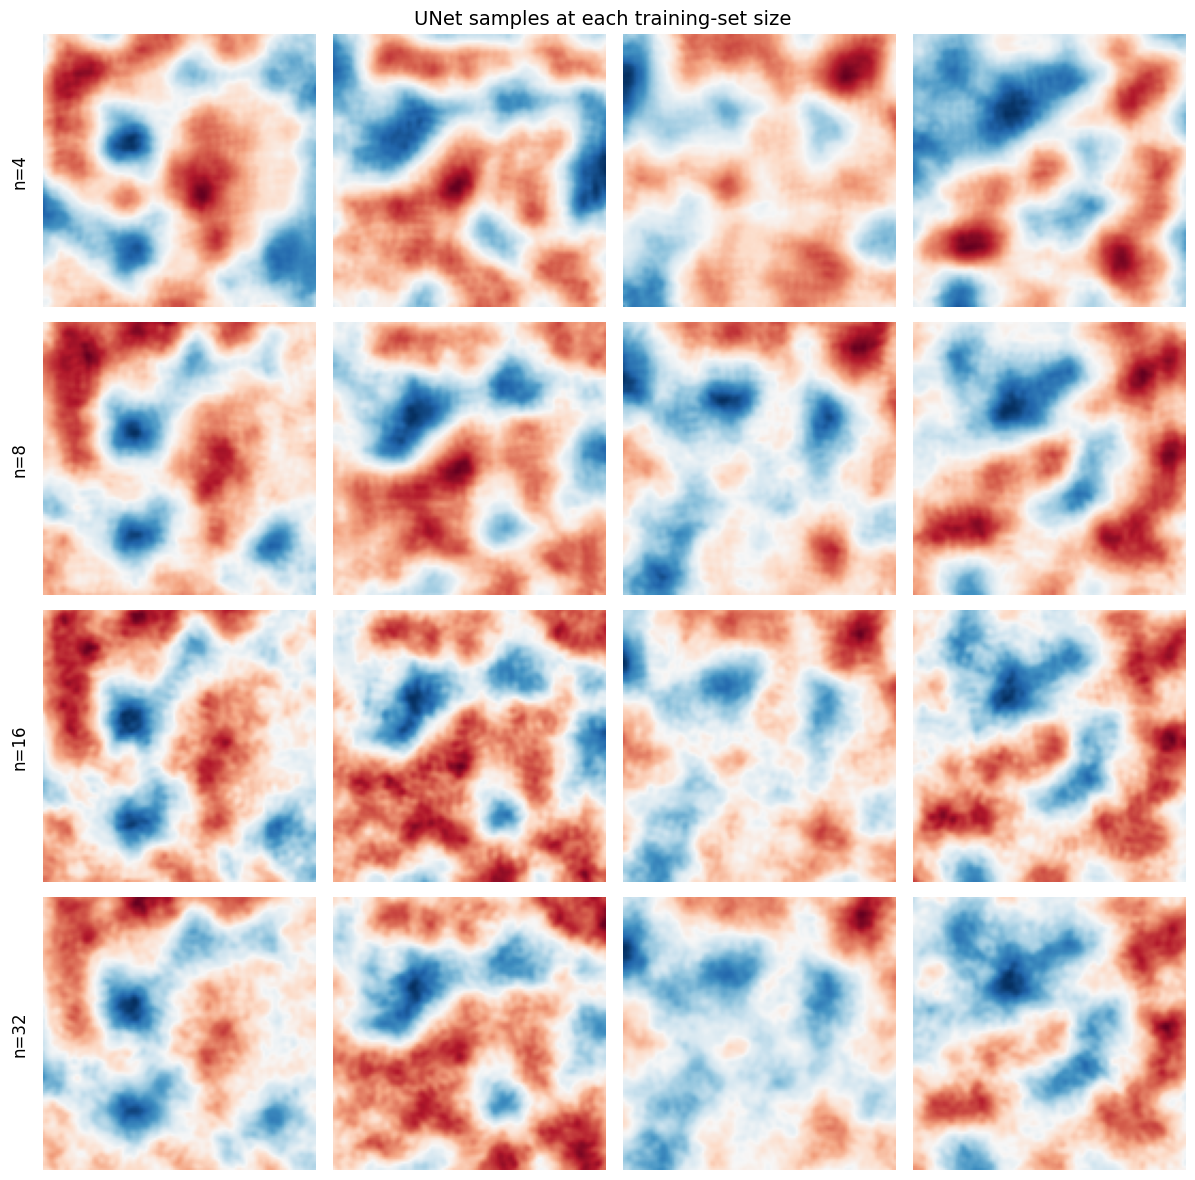

In [9]:
# ── Generated samples per n_train (final checkpoint) ──
n_show = 4
fig, axes = plt.subplots(len(N_TRAIN_SWEEP), n_show, figsize=(3*n_show, 3*len(N_TRAIN_SWEEP)))
for r, n_train in enumerate(N_TRAIN_SWEEP):
    s = sweep_results[n_train]['unet'][TOTAL_STEPS]['samples']
    for col in range(n_show):
        axes[r, col].imshow(s[col].numpy(), cmap='RdBu')
        axes[r, col].axis('off')
    axes[r, 0].text(-0.12, 0.5, f'n={n_train}', transform=axes[r, 0].transAxes,
                    rotation=90, va='center', fontsize=12)
plt.suptitle('UNet samples at each training-set size', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# ── Summary table and save ──
print(f'{"n_train":>8s} | {"UNet coarse":>11s} {"UNet fine":>10s} | '
      f'{"GMM coarse":>10s} {"GMM fine":>9s} | {"UNet/GMM coarse":>15s}')
print('-' * 78)
for n_train in N_TRAIN_SWEEP:
    uc  = sweep_results[n_train]['unet'][TOTAL_STEPS]['coarse_score'].mean().item()
    uf  = sweep_results[n_train]['unet'][TOTAL_STEPS]['fine_score'].mean().item()
    gc_ = sweep_results[n_train]['gmm']['coarse_score'].mean().item()
    gf  = sweep_results[n_train]['gmm']['fine_score'].mean().item()
    print(f'{n_train:>8d} | {uc:>11.4f} {uf:>10.4f} | {gc_:>10.4f} {gf:>9.4f} | '
          f'{uc/max(gc_, 1e-9):>15.2f}')

results_dir = os.path.join(repo_root, 'results', 'data')
os.makedirs(results_dir, exist_ok=True)
save_obj = {
    'n_train_values': N_TRAIN_SWEEP,
    'checkpoint_steps': CHECKPOINT_AT,
    'sweep_results': sweep_results,
    'k_centers': k_centers.cpu(),
    'bands': bands,
    'n_gen': N_GEN,
    'note': ('EDM UNet (unregularized, c_tikhonov=0) trained at n_train in [4,8,16,32], '
             'full batch, 5000 steps, checkpoints [1000,3000,5000]. GMM closed-form score at '
             'the same n_train/latents as memorization ceiling. VE_EDM diffusion, 500-step '
             'SDE, 16 samples, latents seed 42, training seed 0.'),
}
save_path = os.path.join(results_dir, 'edm_unet_train_size_sweep.pt')
torch.save(save_obj, save_path)
print(f'\nResults saved to {save_path}')

 n_train | UNet coarse  UNet fine | GMM coarse  GMM fine | UNet/GMM coarse
------------------------------------------------------------------------------
       4 |      0.9112     0.9979 |     0.2169    0.2234 |            4.20
       8 |      0.8787     1.0016 |     0.1192    0.1266 |            7.37
      16 |      0.8144     1.0015 |     0.0743    0.0820 |           10.96
      32 |      0.8081     0.9996 |     0.0294    0.0375 |           27.52

Results saved to /Users/ishittaiyer/Desktop/Research/results/data/edm_unet_train_size_sweep.pt


## What to look for / next steps

- **Does the UNet approach the GMM ceiling as n_train shrinks?** If at n_train = 4–8 the
  UNet curves collapse onto the dashed GMM curves at low-k, the UNet is in a clear
  memorization regime — the right baseline for testing regularizers.
- **Pick the working n_train.** The most useful value for the regularization experiments is
  the one with a strong, unambiguous memorization signal at low-k while fine-k is not fully
  collapsed (mean_ratio crossing 1 somewhere mid-spectrum is the most informative shape).
- **Then:** re-run the training-time Tikhonov sweep of `edm_tikhonov_memorization.ipynb` at
  that n_train, and eventually the covariance-weighted training-time penalty
  c·λ(σ)·‖D_θ − x‖²_Σ (see `gmm_covariance_tikhonov_memorization.ipynb` for the Σ machinery).